In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from isca_emulation_v2.data.utils import load_isca_result_data
from isca_emulation_v2.plotting.plotting_functions import (
    plot_isca_result,
    plot_isca_absolute_vorticity,
    plot_isca_absolute_vorticity_for_paper,
)

## 1. ISCA no SSW

In [2]:
path_no_ssw = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_no_ssw_L60"
file_name ="atmos_daily_interp.nc"

ds_no_ssw = load_isca_result_data(path_no_ssw, file_name)

/home/obola/miniconda3/envs/isca_emulator/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 Time-series of zonal wind 60north, 10hpa

In [42]:
# ucomp(time, pfull, lat, lon)
u_no_ssw = ds_no_ssw["ucomp"]
u_no_ssw_60N_p10 = u_no_ssw.sel(pfull=10, lat=60, method="nearest")

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_no_ssw_60N_p10_mean = u_no_ssw_60N_p10.mean(dim="lon")

# A selected longitude (e.g., 0°E):
u_no_ssw_60N_p10_lon0 = u_no_ssw_60N_p10.sel(lon=0, method="nearest")

# Force data into memory, then convert to NumPy
u_no_ssw_60N_p10_mean_np = u_no_ssw_60N_p10_mean.load().to_numpy()
u_no_ssw_60N_p10_lon0_np = u_no_ssw_60N_p10_lon0.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_no_ssw = u_no_ssw_60N_p10["time"].to_numpy()

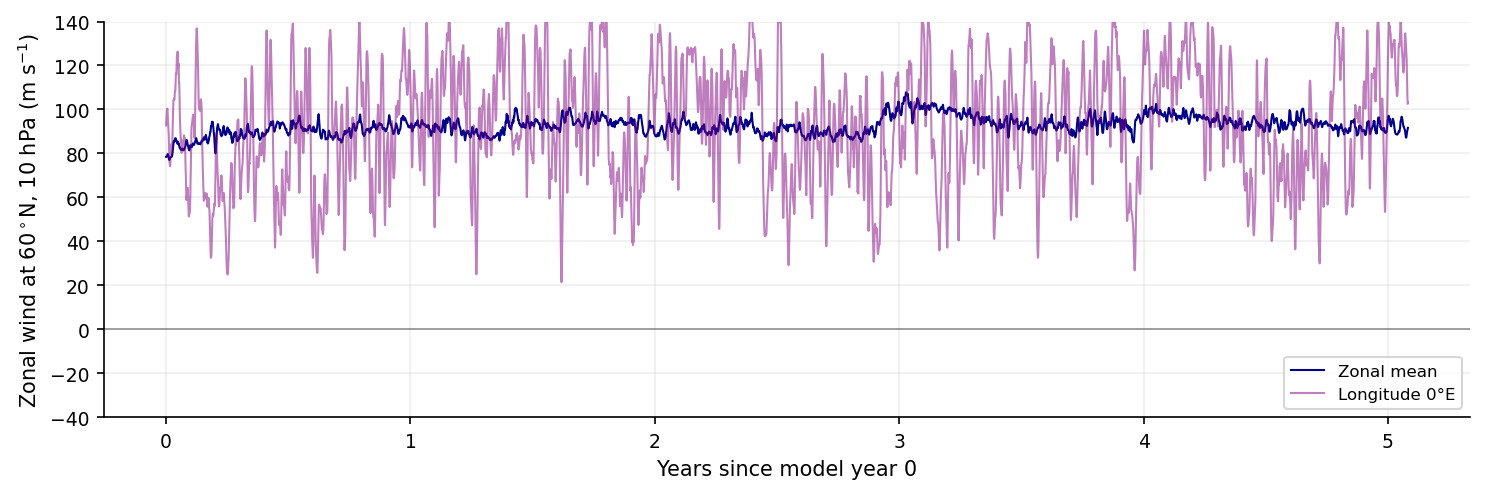

In [34]:
t0 = time_np_no_ssw[0]  # reference time (model year 0)
t_hours = time_np_no_ssw.astype(float)

years_since_0 = (t_hours - t0) / (24 * 365.0)
months_since_0 = (t_hours - t0) / (24 * 30.0)  # approx months

fig, ax = plt.subplots(figsize=(10, 3.4), dpi=150)

# TO ADD blue for poster
# background_rgb = np.array([47, 62, 234]) / 255
# tint = 0.9
# boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
# fig.patch.set_facecolor(boxcolor)   # full figure background
# ax.set_facecolor(boxcolor)          # axes / plotting area background

ax.plot(years_since_0, u_no_ssw_60N_p10_mean_np, lw=1.0, alpha=1, color='darkblue')
ax.plot(years_since_0, u_no_ssw_60N_p10_lon0_np, lw=1.0, alpha=0.5, color='purple')
ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)

ax.set_xlabel("Years since model year 0")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.legend(["Zonal mean", "Longitude 0°E"], fontsize=8, loc="lower right", frameon=True)
#ax.set_title("No SSW", fontsize=10, pad=6)

ax.set_ylim(-40, 140)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### 1.2 Zonal mean presurre / lat 

In [6]:
zonal_mean_pressure_lat_no_ssw = u_no_ssw.mean(dim=["time", "lon"]).load().to_numpy()

pressure_levels_no_ssw = u_no_ssw['pfull'].values
latitude_levels_no_ssw = u_no_ssw['lat'].values

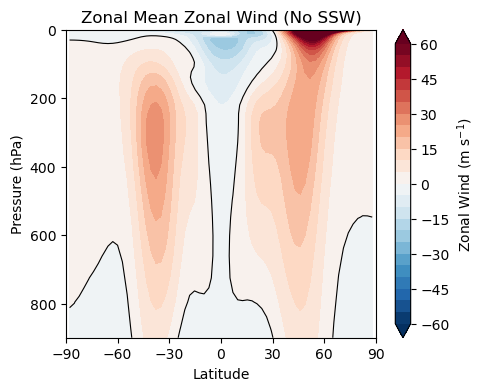

In [7]:
pressure_levels_starting = 12
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)
norm = TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)

cf = ax.contourf(
    latitude_levels_no_ssw,
    pressure_levels_no_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_no_ssw[pressure_levels_starting:],
    levels=levels,
    cmap="RdBu_r",
    norm=norm,
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_no_ssw,
    pressure_levels_no_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_no_ssw[pressure_levels_starting:],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (No SSW)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

## 2. ISCA with SSW

In [3]:
path_with_ssw = "/home/obola/repositories/isca_emulation_v2/data/raw/Oskar_data_generation_large_run_q6m2y45l800u200_L60"
file_name ="atmos_daily_interp.nc"

ds_with_ssw = load_isca_result_data(path_with_ssw, file_name)

### 2.1 Time-series of zonal wind 60north, 10hpa

In [41]:
# ucomp(time, pfull, lat, lon)
u_with_ssw = ds_with_ssw["ucomp"]
u_with_ssw_60N_p10 = u_with_ssw.sel(pfull=10, lat=60, method="nearest")

# If you mean pfull value ~10 hPa and lat 60N (use nearest grid point), then zonal mean:
u_with_ssw_60N_p10_mean = u_with_ssw_60N_p10.mean(dim="lon")

# A selected longitude (e.g., 0°E):
u_with_ssw_60N_p10_lon0 = u_with_ssw_60N_p10.sel(lon=0, method="nearest")

# Force data into memory, then convert to NumPy
u_with_ssw_60N_p10_mean_np = u_with_ssw_60N_p10_mean.load().to_numpy()
u_with_ssw_60N_p10_lon0_np = u_with_ssw_60N_p10_lon0.load().to_numpy()

# Optional: matching time axis as NumPy
time_np_with_ssw = u_with_ssw_60N_p10["time"].to_numpy()

In [ ]:
t0 = time_np_with_ssw[0]  # reference time (model year 0)
t_hours = time_np_with_ssw.astype(float)

years_since_0 = (t_hours - t0) / (24 * 365.0)
months_since_0 = (t_hours - t0) / (24 * 30.0)  # approx months

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=150)

# # TO ADD blue for poster
# background_rgb = np.array([47, 62, 234]) / 255
# tint = 0.9
# boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
# fig.patch.set_facecolor(boxcolor)   # full figure background
# ax.set_facecolor(boxcolor)          # axes / plotting area background

ax.plot(years_since_0, u_with_ssw_60N_p10_mean_np, lw=1.0, alpha=1, color='darkblue')
ax.plot(years_since_0, u_with_ssw_60N_p10_lon0_np, lw=1.0, alpha=0.5, color='purple')

ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)
# ax.axvline(years_since_0[400], lw=0.8, color="red", alpha=0.7, ls="--")
# ax.axvline(years_since_0[2100], lw=0.8, color="red", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3001], lw=0.8, color="blue", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3250], lw=0.8, color="blue", alpha=0.7, ls="--")
# ax.axvline(years_since_0[3251], lw=0.8, color="green", alpha=0.7, ls="--")
ax.axvline(years_since_0[3500], lw=0.8, color="green", alpha=0.7, ls="--")
# ax.axvline(years_since_0[4300], lw=0.8, color="yellow", alpha=0.7, ls="--")
# ax.axvline(years_since_0[5000], lw=0.8, color="yellow", alpha=0.7, ls="--")

ax.set_xlabel("Years since model year 0")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.legend(["Zonal mean", "Longitude 0°E"], fontsize=8, loc="lower right", frameon=True)
#ax.set_title("With SSW", fontsize=10, pad=6)

ax.set_ylim(-40, 140)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)


plt.tight_layout()
plt.show()

NameError: name 'time_np_with_ssw' is not defined

### 2.2 Time-series of zonal wind 60north, 10hpa --> identify SSWs

Detected 6 distinct SSW crossings (after filtering).


,SSW_event_date,ssw_event_date_minus10
0,1276,1196
1,4698,4618
2,5387,5307
3,7781,7701
4,13869,13789
5,14533,14453


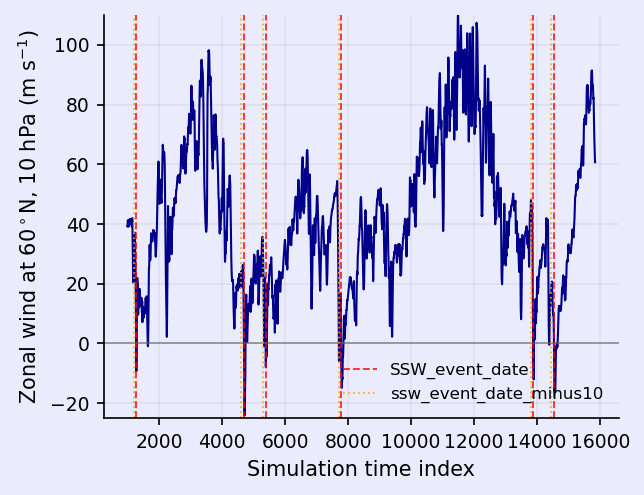

In [10]:
import pandas as pd
from IPython.display import display

# 1) 10 hPa, 60N zonal-mean wind time series (skip early spin-up segment)
steps_per_day = 8  # atmos_daily_interp.nc is 3-hourly
spinup_steps = 1000

u10_60 = (
    ds_with_ssw["ucomp"]
    .isel(time=slice(spinup_steps, None))
    .sel(pfull=10, lat=60, method="nearest")
    .mean("lon")
    .load()
)

# 2) SSW onset candidate: first crossing from >0 to <=0
crossings = ((u10_60.shift(time=1) > 0) & (u10_60 <= 0)).fillna(False)
raw_idx = np.where(crossings.values)[0]

# 3) Keep robust/distinct events
min_neg_days = 2   # must remain negative for at least 2 days after onset
min_sep_days = 30  # minimum separation between accepted events
min_neg_steps = min_neg_days * steps_per_day
min_sep_steps = min_sep_days * steps_per_day

event_idx = []
for i in raw_idx:
    if i + min_neg_steps > u10_60.sizes["time"]:
        continue
    if not bool((u10_60.isel(time=slice(i, i + min_neg_steps)) < 0).all()):
        continue
    if len(event_idx) == 0 or (i - event_idx[-1]) >= min_sep_steps:
        event_idx.append(int(i))

event_idx = np.array(event_idx, dtype=int)

# Convert to full ds_with_ssw time indices (simulation index)
event_idx_full = event_idx + spinup_steps
pre10_idx_full = np.maximum(event_idx_full - 10 * steps_per_day, 0)

ssw_event_summary = pd.DataFrame(
    {
        "SSW_event_date": event_idx_full,
        "ssw_event_date_minus10": pre10_idx_full,
    }
)

print(f"Detected {len(ssw_event_summary)} distinct SSW crossings (after filtering).")
display(ssw_event_summary)

# 4) Same chart + vertical lines for event and event-10d indices
u10_60_np = u10_60.to_numpy()
time_idx = np.arange(spinup_steps, spinup_steps + u10_60.sizes["time"])

fig, ax = plt.subplots(figsize=(4.4, 3.4), dpi=150)

background_rgb = np.array([47, 62, 234]) / 255
tint = 0.9
boxcolor = tuple((1 - tint) * background_rgb + tint * np.ones(3))
fig.patch.set_facecolor(boxcolor)
ax.set_facecolor(boxcolor)

ax.plot(time_idx, u10_60_np, lw=1.0, alpha=1, color="darkblue")
ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)

for j, x in enumerate(event_idx_full):
    ax.axvline(
        x,
        lw=0.9,
        color="red",
        alpha=0.8,
        ls="--",
        label="SSW_event_date" if j == 0 else None,
    )

for j, x in enumerate(pre10_idx_full):
    ax.axvline(
        x,
        lw=0.9,
        color="orange",
        alpha=0.8,
        ls=":",
        label="ssw_event_date_minus10" if j == 0 else None,
    )

ax.set_xlabel("Simulation time index")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)")
ax.set_ylim(-25, 110)
ax.grid(True, alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)
ax.legend(fontsize=8, loc="lower right", frameon=False)

plt.tight_layout()
plt.show()



In [11]:
steps_per_day = 8

n_events = len(ssw_event_summary)
n_steps_analyzed = u10_60.sizes["time"]
n_days_analyzed = n_steps_analyzed / steps_per_day
n_years_analyzed = n_days_analyzed / 360  # 30-day-month calendar

freq_per_100_days = n_events / n_days_analyzed * 100
freq_per_year = n_events / n_years_analyzed

print(f"Events: {n_events}")
print(f"Analyzed length: {n_days_analyzed:.1f} days = {n_years_analyzed:.2f} model years")
print(f"SSW frequency: {freq_per_100_days:.2f} events per 100 days")
print(f"SSW frequency: {freq_per_year:.2f} events per 360-day model year")

Events: 6
Analyzed length: 1855.0 days = 5.15 model years
SSW frequency: 0.32 events per 100 days
SSW frequency: 1.16 events per 360-day model year


### 2.3 Zonal mean lattitude / pressure

In [127]:
## get the data needed
u_with_ssw = ds_with_ssw["ucomp"][1000:]

zonal_mean_pressure_lat_with_ssw = u_with_ssw.mean(dim=["time", "lon"]).load().to_numpy()

pressure_levels_with_ssw = u_with_ssw['pfull'].values
latitude_levels_with_ssw = u_with_ssw['lat'].values

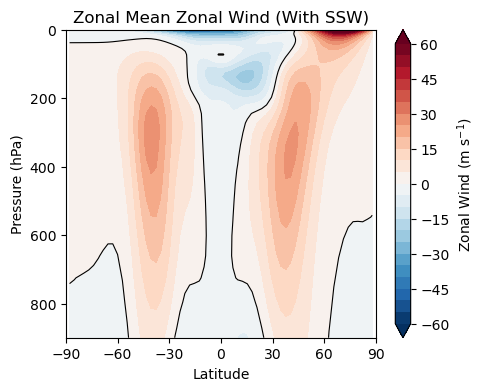

In [141]:
pressure_levels_starting = 12
# Make the plot
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)

cf = ax.contourf(
    latitude_levels_with_ssw,
    pressure_levels_with_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_with_ssw[pressure_levels_starting:],
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_with_ssw,
    pressure_levels_with_ssw[pressure_levels_starting:],
    zonal_mean_pressure_lat_with_ssw[pressure_levels_starting:],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (With SSW)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

### 2.3 Dripping paint plot proxy

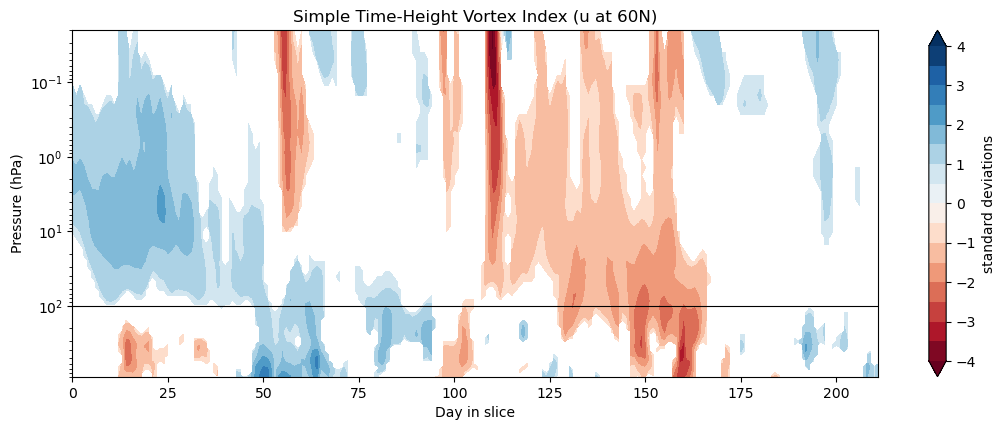

In [57]:
import numpy as np
import matplotlib.pyplot as plt

ds = ds_with_ssw.isel(time=slice(400, 2100))

# 3-hourly -> daily mean (8 steps/day)
ds_day = ds.coarsen(time=8, boundary="trim").mean()

# Simple index matrix: zonal-mean zonal wind at 60N (time, pfull)
I = ds_day["ucomp"].mean("lon").interp(lat=60)

# Standardize each pressure level (nondimensional)
I = (I - I.mean("time")) / I.std("time")

# Match figure style: leave -0.5..0.5 unshaded
I_plot = I.where(np.abs(I) >= 0.8)
levels = np.arange(-4.0, 4.5, 0.5)

fig, ax = plt.subplots(figsize=(13, 4.5))
cf = ax.contourf(
    np.arange(I_plot.sizes["time"]),
    I_plot["pfull"].values,
    I_plot.transpose("pfull", "time").values,
    levels=levels,
    cmap="RdBu",
    extend="both",
)
ax.set_yscale("log")
ax.set_ylim(float(I_plot["pfull"].max()), float(I_plot["pfull"].min()))
ax.axhline(100, color="k", lw=0.8)
ax.set_xlabel("Day in slice")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Simple Time-Height Vortex Index (u at 60N)")
plt.colorbar(cf, ax=ax, label="standard deviations")
plt.show()


## 3. JRA 55 data

In [104]:
path_to_jra = "/home/obola/repositories/isca_emulation_v2/notebooks/data_for_paper/mthm051_jra_55_monthly_av_1958_2016.nc"
ds_jra = xr.open_dataset(path_to_jra)

In [121]:
u_jra = ds_jra["ucomp"].where(ds_jra["month"].isin([12, 1, 2]), drop=True)
u_jra_zonal_mean_pressure_lat_jra = u_jra.mean(dim=["month", "lon"]).load().to_numpy()

pressure_levels_jra = u_jra['pfull_2'].values/100
latitude_levels_jra = u_jra['lat'].values

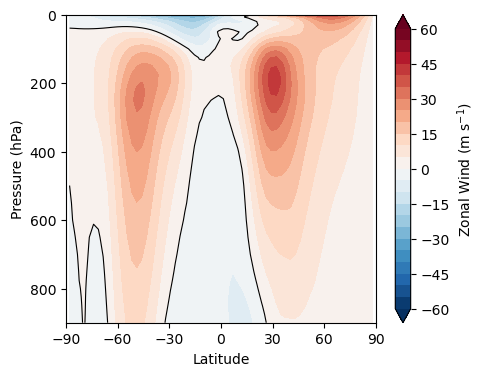

In [ ]:
num_pressure_levels_used = 33
# Make the plot
fig, ax = plt.subplots(figsize=(5, 4))

levels = np.arange(-60, 61, 5)

cf = ax.contourf(
    latitude_levels_jra,
    pressure_levels_jra[:num_pressure_levels_used],
    u_jra_zonal_mean_pressure_lat_jra[:num_pressure_levels_used],
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)

# Emphasize zero contour
cz = ax.contour(
    latitude_levels_jra,
    pressure_levels_jra[:num_pressure_levels_used],
    u_jra_zonal_mean_pressure_lat_jra[:num_pressure_levels_used],
    levels=[0],
    colors="black",
    linewidths=0.8,
)

#ax.set_yscale("log")
ax.set_yticks([800, 600, 400, 200, 0])
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Zonal Mean Zonal Wind (JRA-55)")

cbar = fig.colorbar(cf, ax=ax, label="Zonal Wind (m s$^{-1}$)")
plt.show()

## 4. Time-series SSW and no-SSW

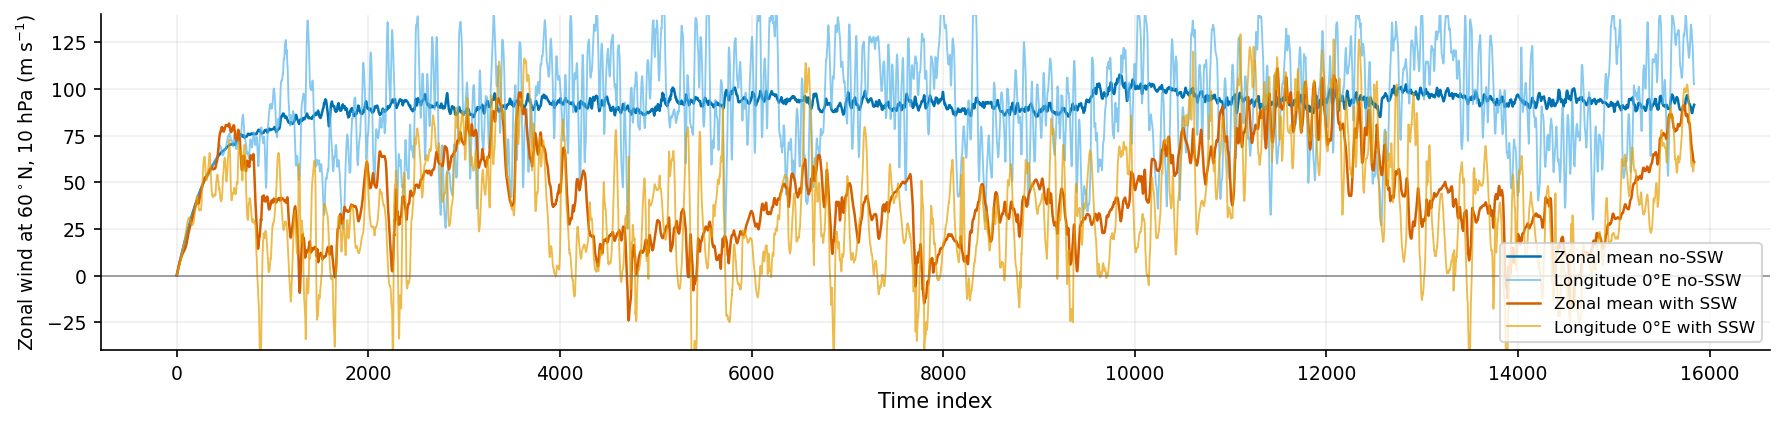

In [53]:
colors = {
    "no_ssw_mean": "#0072B2",   # blue
    "no_ssw_lon0": "#56B4E9",   # light blue
    "with_ssw_mean": "#D55E00", # vermilion
    "with_ssw_lon0": "#E69F00", # orange
}

time_index = np.arange(len(time_np_no_ssw))

fig, ax = plt.subplots(figsize=(12, 3), dpi=150)

ax.plot(time_index, u_no_ssw_60N_p10_mean_np,
        color=colors["no_ssw_mean"], lw=1.2)

ax.plot(time_index, u_no_ssw_60N_p10_lon0_np,
        color=colors["no_ssw_lon0"], lw=0.9, alpha=0.7)

ax.plot(time_index, u_with_ssw_60N_p10_mean_np,
        color=colors["with_ssw_mean"], lw=1.2)

ax.plot(time_index, u_with_ssw_60N_p10_lon0_np,
        color=colors["with_ssw_lon0"], lw=0.9, alpha=0.7)
ax.axhline(0, lw=0.8, color="0.4", alpha=0.7)

ax.set_xlabel("Time index")
ax.set_ylabel(r"Zonal wind at 60$^\circ$N, 10 hPa (m s$^{-1}$)", fontsize=9)

ax.legend(
    [
        "Zonal mean no-SSW",
        "Longitude 0°E no-SSW",
        "Zonal mean with SSW",
        "Longitude 0°E with SSW",
    ],
    fontsize=8,
    loc="lower right",
    frameon=True,
)

ax.set_ylim(-40, 140)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 4. Absolute vorticity under SSWs

In [11]:
AVORT_TIME_INDEX = 3500
AVORT_TIME_INDEX_NO_SSW = 3500
AVORT_TIME_INDEX_WITH_SSW = (1276, 4698)
AVORT_PRESSURE_LEVELS_HPA = (10.0,)
AVORT_MIN_LAT = 20
AVORT_PANEL_PORT = 5007

In [9]:
plot_isca_absolute_vorticity(
    ds_with_ssw,
    time_index=AVORT_TIME_INDEX,
    pressure_levels_hpa=AVORT_PRESSURE_LEVELS_HPA,
    min_lat=AVORT_MIN_LAT,
    port=AVORT_PANEL_PORT,
)


/home/obola/repositories/isca_emulation_v2/src/isca_emulation_v2/plotting/plotting_functions.py:308: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension()


Launching server at http://127.0.0.1:5007


### 4.1 Static absolute-vorticity figure for the paper

In [ ]:
fig, axes = plot_isca_absolute_vorticity_for_paper(
    ds_no_ssw,
    ds_with_ssw,
    time_index_no_ssw=AVORT_TIME_INDEX_NO_SSW,
    time_indices_with_ssw=AVORT_TIME_INDEX_WITH_SSW,
    pressure_levels_hpa=AVORT_PRESSURE_LEVELS_HPA,
    min_lat=AVORT_MIN_LAT,
)

## 5. ISCA dashboard

In [4]:
vars_cfg = ["temp", "ucomp", "vcomp"]
times = ds_no_ssw['time'].values
pvals = ds_no_ssw['pfull'].values.astype(float)

ds_preview = ds_no_ssw.isel(
    time=slice(500, 2000),      
    pfull=slice(None, None, 1),
    lat=slice(None, None, 1),
    lon=slice(None, None, 1))

times_preview = ds_preview["time"].values
pvals_preview = ds_preview["pfull"].values.astype(float)

plot_isca_result(ds_preview, times_preview, pvals_preview, vars_cfg)

/home/obola/repositories/isca_emulation_v2/src/isca_emulation_v2/plotting/plotting_functions.py:124: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension()


Launching server at http://127.0.0.1:35133
